# Task 2: News Category Classification

Classify AG News articles into **World**, **Sports**, **Business**, or **Sci/Tech** using classic NLP preprocessing, TF-IDF feature engineering, and multiple multiclass classifiers.

## 1. Install Libraries

In [1]:
%pip install -q pandas scikit-learn nltk wordcloud matplotlib tensorflow

## 2. Import Libraries

In [2]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Optional NLTK setup (used for stopwords + lemmatization) ---
# Falls back gracefully if NLTK data can't be downloaded (e.g. no internet access),
# so the notebook still runs end-to-end either way.
NLTK_READY = False
try:
    import nltk
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
    from nltk.corpus import stopwords as nltk_stopwords
    from nltk.stem import WordNetLemmatizer
    STOPWORDS = set(nltk_stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    _ = lemmatizer.lemmatize("testing")  # touches the wordnet corpus; raises if data is missing
    NLTK_READY = True
except Exception as e:
    print(f"[info] NLTK stopwords/WordNet not available ({type(e).__name__}); "
          f"falling back to scikit-learn's built-in stopword list and a lightweight rule-based lemmatizer.")
    STOPWORDS = set(ENGLISH_STOP_WORDS)
    lemmatizer = None

print("NLTK lemmatizer ready:", NLTK_READY)
print("Stopword list size:", len(STOPWORDS))

NLTK lemmatizer ready: True
Stopword list size: 198


## 3. Load the Dataset

AG News (Kaggle), provided as `train.csv` / `test.csv` with columns `Class Index`, `Title`, `Description`. Class indices map to: `1=World, 2=Sports, 3=Business, 4=Sci/Tech`.

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

LABEL_MAP = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
train_df["Category"] = train_df["Class Index"].map(LABEL_MAP)
test_df["Category"] = test_df["Class Index"].map(LABEL_MAP)

# Combine title + description into a single text field
train_df["text"] = train_df["Title"] + ". " + train_df["Description"]
test_df["text"] = test_df["Title"] + ". " + test_df["Description"]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df[["Category", "text"]].head(3)

Train shape: (120000, 5)
Test shape: (7600, 5)


,Category,text
0,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...


## 4. Exploratory Data Analysis: Class Distribution

Category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


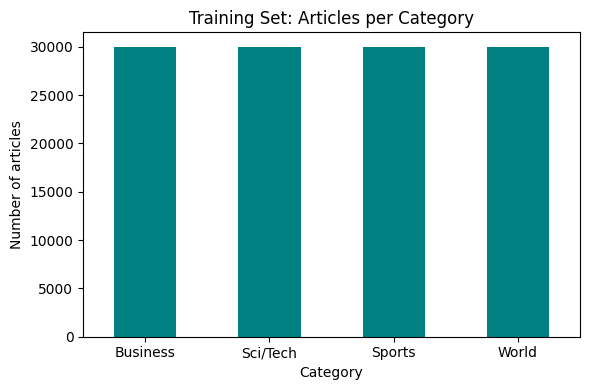

In [4]:
class_counts = train_df["Category"].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color="teal")
plt.title("Training Set: Articles per Category")
plt.ylabel("Number of articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Text Preprocessing

Standard pipeline: lowercase -> remove non-alphabetic characters -> tokenize -> remove stopwords -> lemmatize.

In [5]:
def simple_lemmatize(word):
    """Very small rule-based fallback used only if NLTK's WordNet data isn't available."""
    for suffix in ("ies",):
        if word.endswith(suffix) and len(word) > 4:
            return word[:-3] + "y"
    for suffix in ("sses", "es"):
        if word.endswith(suffix) and len(word) > 4:
            return word[:-2]
    for suffix in ("ing", "ed"):
        if word.endswith(suffix) and len(word) > 5:
            return word[:-len(suffix)]
    if word.endswith("s") and not word.endswith("ss") and len(word) > 3:
        return word[:-1]
    return word


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)      # remove punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()                        # tokenization
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # stopword removal
    if NLTK_READY:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]             # lemmatization
    else:
        tokens = [simple_lemmatize(t) for t in tokens]
    return " ".join(tokens)


train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Before:", train_df["text"].iloc[0][:120])
print("After: ", train_df["clean_text"].iloc[0][:120])

Before: Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics
After:  wall bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green


## 6. Feature Engineering: TF-IDF Vectorization

In [6]:
tfidf = TfidfVectorizer(max_features=15000, sublinear_tf=True)
X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["Category"]
y_test = test_df["Category"]

print("TF-IDF train matrix:", X_train.shape)
print("TF-IDF test matrix: ", X_test.shape)

TF-IDF train matrix: (120000, 15000)
TF-IDF test matrix:  (7600, 15000)


## 7. Train Multiclass Classifiers

Three classic multiclass classifiers are compared: Logistic Regression, Linear SVM, and Random Forest.

In [7]:
results = {}
fitted_models = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"accuracy": acc, "macro_f1": f1}
    fitted_models[name] = model
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_test, preds, digits=3))
    return preds

_ = evaluate_model("Logistic Regression", LogisticRegression(max_iter=300))
_ = evaluate_model("Linear SVM", LinearSVC())
_ = evaluate_model("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=50, random_state=42))

--- Logistic Regression ---
Accuracy: 0.9097 | Macro F1: 0.9096
              precision    recall  f1-score   support

    Business      0.872     0.868     0.870      1900
    Sci/Tech      0.886     0.895     0.891      1900
      Sports      0.953     0.979     0.966      1900
       World      0.926     0.897     0.912      1900

    accuracy                          0.910      7600
   macro avg      0.910     0.910     0.910      7600
weighted avg      0.910     0.910     0.910      7600

--- Linear SVM ---
Accuracy: 0.9124 | Macro F1: 0.9123
              precision    recall  f1-score   support

    Business      0.873     0.877     0.875      1900
    Sci/Tech      0.885     0.896     0.890      1900
      Sports      0.959     0.977     0.968      1900
       World      0.932     0.899     0.916      1900

    accuracy                          0.912      7600
   macro avg      0.912     0.912     0.912      7600
weighted avg      0.912     0.912     0.912      7600

--- Random 

### Model Comparison

                     accuracy  macro_f1
Logistic Regression  0.909737  0.909552
Linear SVM           0.912368  0.912303
Random Forest        0.857500  0.856377


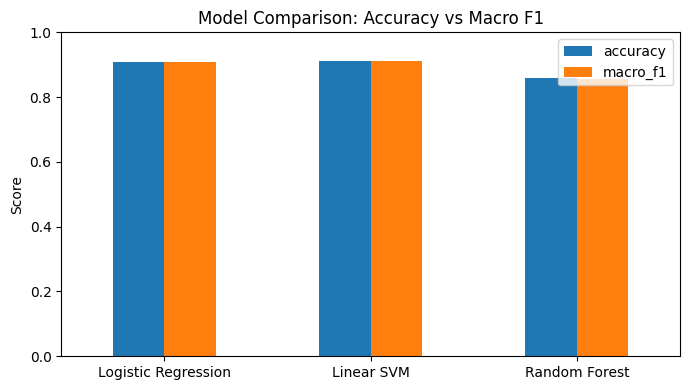

In [8]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind="bar", figsize=(7, 4))
plt.title("Model Comparison: Accuracy vs Macro F1")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Confusion Matrix (Best Model)

Best model: Linear SVM


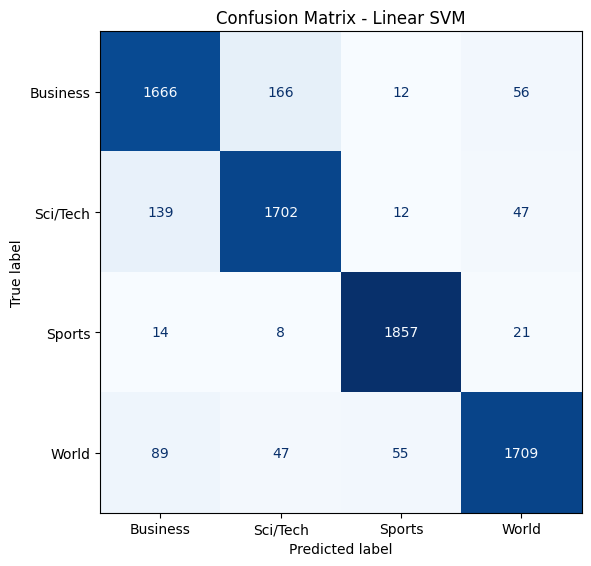

In [9]:
best_name = results_df["accuracy"].idxmax()
best_model = fitted_models[best_name]
print("Best model:", best_name)

preds_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds_best, labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

## 8. Bonus: Most Frequent Words per Category

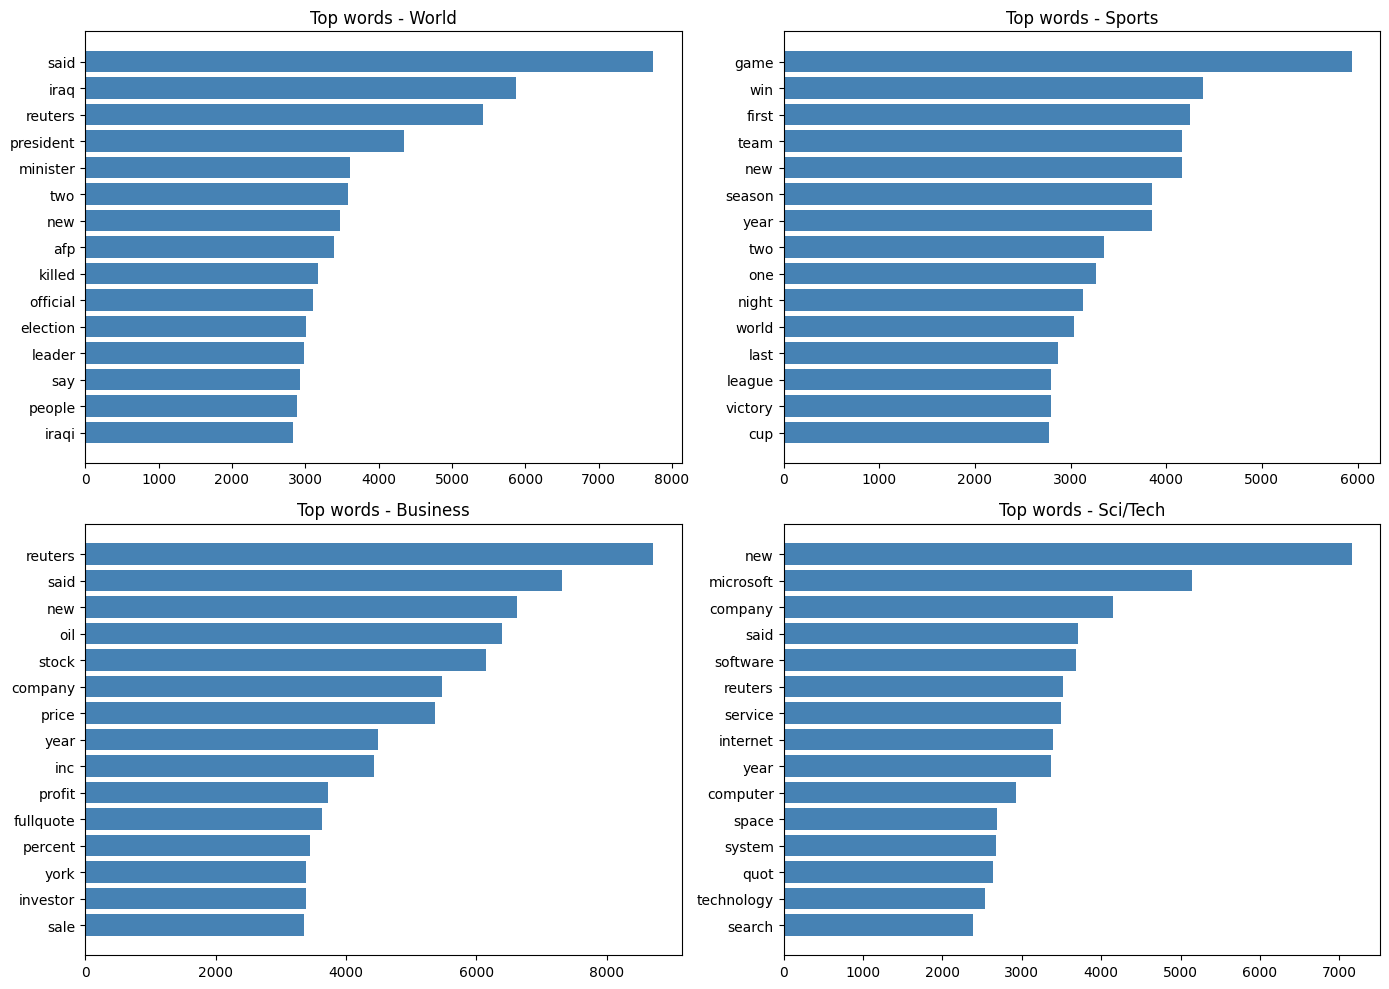

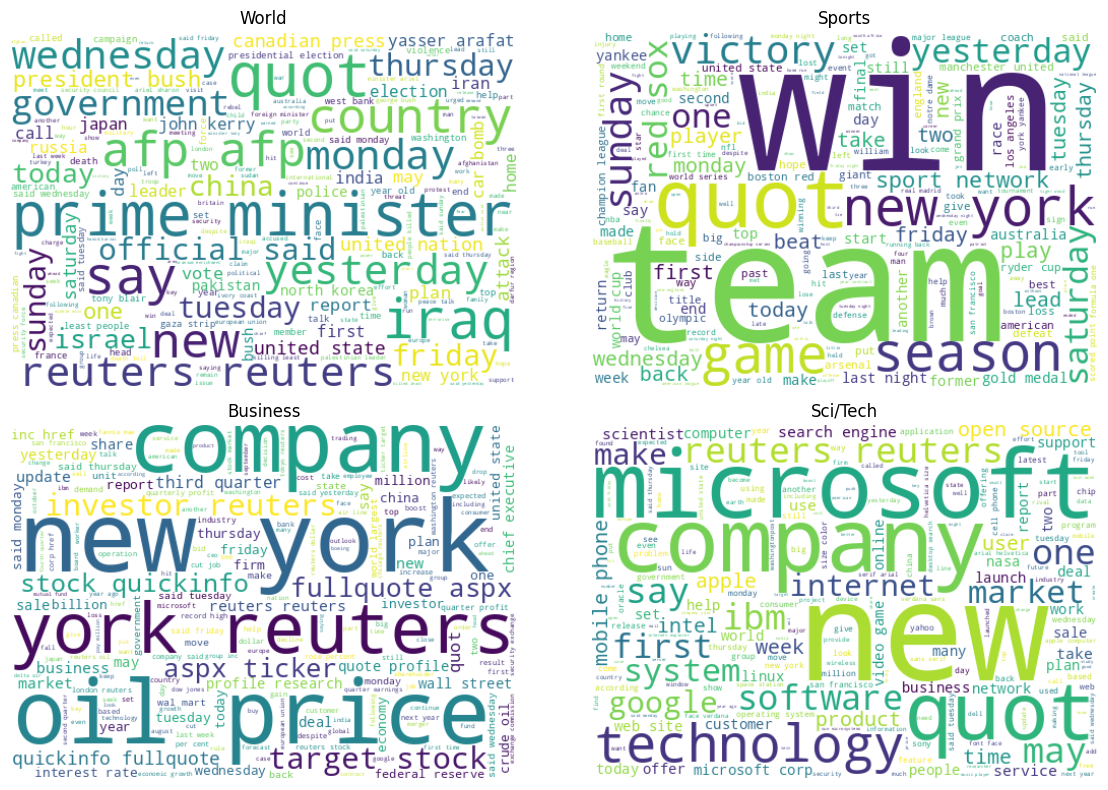

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cat in zip(axes, LABEL_MAP.values()):
    texts = train_df.loc[train_df["Category"] == cat, "clean_text"]
    cv = CountVectorizer(max_features=15)
    X_cv = cv.fit_transform(texts)
    freqs = X_cv.sum(axis=0).A1
    words = cv.get_feature_names_out()
    order = freqs.argsort()[::-1]
    ax.barh([words[i] for i in order][::-1], [freqs[i] for i in order][::-1], color="steelblue")
    ax.set_title(f"Top words - {cat}")

plt.tight_layout()
plt.show()

# Optional: word clouds (only if the `wordcloud` package is installed)
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for ax, cat in zip(axes, LABEL_MAP.values()):
        text_blob = " ".join(train_df.loc[train_df["Category"] == cat, "clean_text"])
        wc = WordCloud(width=500, height=350, background_color="white").generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(cat)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("[info] `wordcloud` package not available in this environment; bar plots above already satisfy the bonus.")

## 9. Bonus: Neural Network Classifier


In [11]:
from sklearn.preprocessing import LabelEncoder

# A smaller TF-IDF representation keeps the dense NN input manageable in memory.
tfidf_nn = TfidfVectorizer(max_features=2000, sublinear_tf=True)

# Using a training subsample keeps this bonus step fast on modest hardware;
# increase NN_TRAIN_SAMPLES (or drop the .sample(...) call) for a full-scale run.
NN_TRAIN_SAMPLES = 40000
train_nn_df = train_df.sample(n=NN_TRAIN_SAMPLES, random_state=42)

X_train_nn = tfidf_nn.fit_transform(train_nn_df["clean_text"]).toarray().astype("float32")
X_test_nn = tfidf_nn.transform(test_df["clean_text"]).toarray().astype("float32")

le = LabelEncoder()
y_train_nn = le.fit_transform(train_nn_df["Category"])
y_test_nn = le.transform(test_df["Category"])

try:
    import tensorflow as tf
    from tensorflow import keras

    nn_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_nn.shape[1],)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(len(le.classes_), activation="softmax"),
    ])
    nn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = nn_model.fit(X_train_nn, y_train_nn, validation_split=0.1, epochs=8, batch_size=64, verbose=0)
    loss, nn_acc = nn_model.evaluate(X_test_nn, y_test_nn, verbose=0)
    print(f"Keras feedforward NN — Test accuracy: {nn_acc:.4f}")

except ImportError:
    print("[info] TensorFlow not available in this environment; using scikit-learn's MLPClassifier "
          "as an equivalent feedforward neural network instead.")
    from sklearn.neural_network import MLPClassifier

    nn_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=25, random_state=42)
    nn_model.fit(X_train_nn, y_train_nn)
    nn_preds = nn_model.predict(X_test_nn)
    nn_acc = accuracy_score(y_test_nn, nn_preds)
    print(f"MLPClassifier feedforward NN — Test accuracy: {nn_acc:.4f}")
    print(classification_report(y_test_nn, nn_preds, target_names=le.classes_, digits=3))

Keras feedforward NN — Test accuracy: 0.8732
